# Imports 

In [1]:
import pandas as pd
from src.setup import get_base
from src.feature_engineering import engineer_features, engineer_features2, engineer_features_combined, engineer_features_optimized, engineer_features_focused
from sklearn.preprocessing import StandardScaler
from src.clustering import SegmentationPipeline

# Data

In [2]:
df = get_base()
df.head()

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,...,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_price_per_room_night_usd
0,101486-6d053e0f51884dddb339416c86d5b3a9,101486,NaN,2023-07-18 09:35:00,2023-07-18 09:35:22,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
1,101486-6de2ac91a8c24619a69a3d3ae7c28d61,101486,NaN,2023-03-21 10:16:00,2023-03-21 10:18:38,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
2,101486-7e8b450e5fe94345bd6c1ae9f479f073,101486,NaN,2023-02-11 17:05:00,2023-02-11 17:07:58,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
3,101486-9e7d5ccc7e034bf7b7a5ad2f3befbe13,101486,NaN,2023-05-30 20:42:00,2023-05-30 20:44:15,True,False,0.1,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
4,101486-be6d02b11839441aa4107044d095cb99,101486,NaN,2023-03-06 21:50:00,2023-03-06 21:50:53,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN


# Features

In [3]:
df_features = engineer_features2(df)
df_features.head()

/Users/kiko/Desktop/github/traveltide/src/feature_engineering.py:186: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_features["flight_discount_ratio"] = grouped.apply(
/Users/kiko/Desktop/github/traveltide/src/feature_engineering.py:214: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_features["flight_hotel_combo_ratio"] = grouped.apply(


,age,gender,married,has_children,n_unique_destinations,avg_flight_fare_usd,total_flight_fare_usd,total_flights_booked,total_hotels_booked,total_flight_discount,avg_flight_discount,flight_discount_ratio,avg_flight_discount_percentage,avg_checked_bags,total_cancellations,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio
user_id,,,,,,,,,,,,,,,,,,
23557,66,0.0,1,0,0,0.000,0.00,0,2,0,0.000,0.000000,0.000000,0.000000,0,0.00,0.000,1.000000
94883,53,0.0,1,0,2,432.045,864.09,2,2,0,0.000,0.000000,0.000000,0.500000,0,0.00,0.250,0.500000
101486,52,0.0,1,1,1,189.910,189.91,1,2,2,0.250,1.999998,0.010531,0.000000,0,0.00,0.125,0.666666
101961,45,0.0,1,0,5,248.532,1242.66,5,5,2,0.250,0.400000,0.001609,0.400000,0,0.00,0.625,0.500000
106907,46,0.0,1,1,1,13902.060,27804.12,2,2,1,0.125,0.500000,0.000036,4.999998,1,0.25,0.250,0.500000


# Clustering

In [4]:
pipe = SegmentationPipeline(variance_threshold=0.95, max_clusters=10)

In [5]:
features_scaled, df_clean = pipe.prepare_features(df_features)

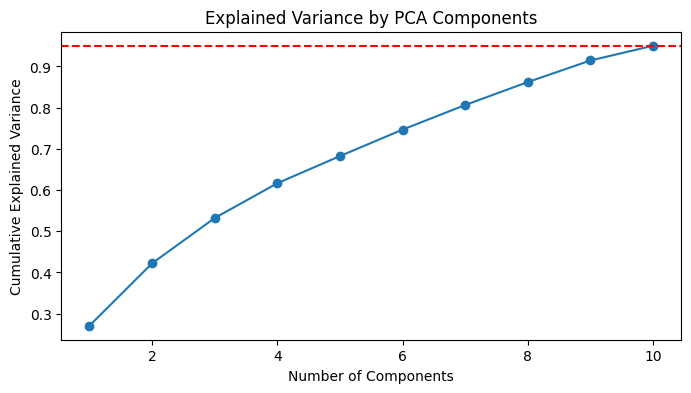

In [6]:
components, pca, explained_var = pipe.run_pca(features_scaled)
pipe.plot_explained_variance()

KMeans with 2 clusters: 0.1709
KMeans with 3 clusters: 0.3298
KMeans with 4 clusters: 0.1773
KMeans with 5 clusters: 0.1869
KMeans with 6 clusters: 0.1778
KMeans with 7 clusters: 0.1840
KMeans with 8 clusters: 0.1977
KMeans with 9 clusters: 0.1884
KMeans with 10 clusters: 0.1808


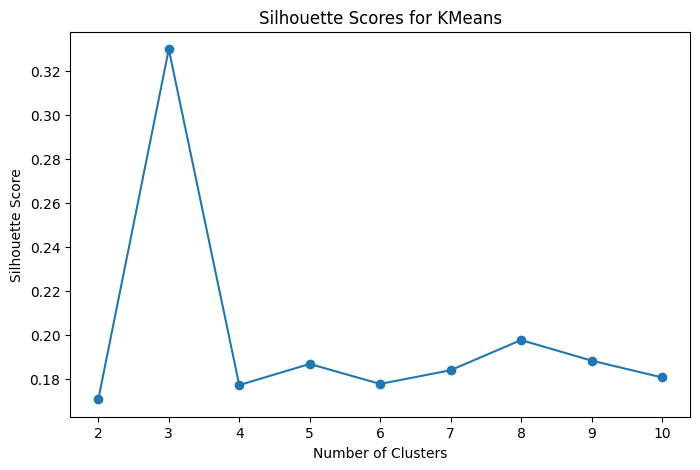

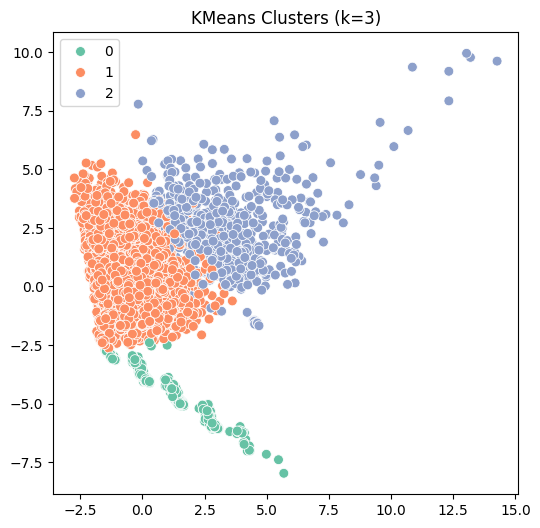

In [7]:
model_auto, scores_auto = pipe.optimized_kmeans_clustering()
pipe.plot_scores()
pipe.plot_clusters()

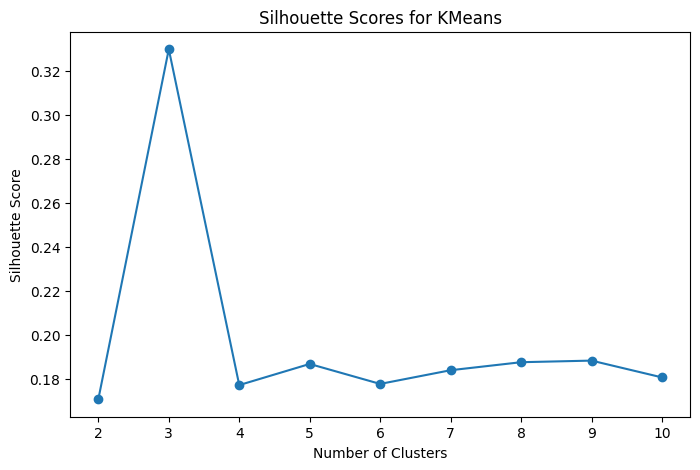

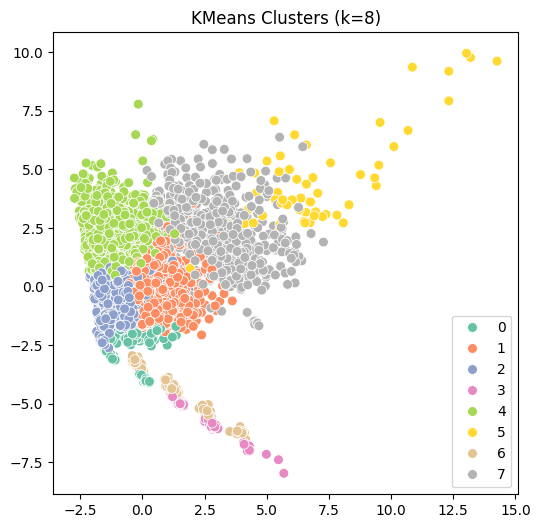

In [8]:
model_fixed, scores_fixed = pipe.kmeans_clustering(n_clusters=8)
pipe.plot_scores()
pipe.plot_clusters()

In [9]:
df_clusters = pipe.assign_clusters(df_features)

# Report
summary = pipe.cluster_summary(df_clusters)
summary.to_csv('../report/summary_clusters.csv')

display(summary)

age                         gender                         ...  \
              mean median min max count      mean median  min  max count  ...   
cluster                                                                   ...   
0        40.115702   34.0  18  90   363  0.123967    0.0  0.0  1.0   363  ...   
1        43.740268   44.0  18  80  1490  0.112081    0.0  0.0  1.0  1490  ...   
2        42.380548   43.0  18  87  1532  0.124674    0.0  0.0  1.0  1532  ...   
3        39.864130   34.5  18  82   184  0.114130    0.0  0.0  1.0   184  ...   
4        45.073359   45.0  18  68  1554  0.102960    0.0  0.0  1.0  1554  ...   
5        41.967213   42.0  19  73    61  0.180328    0.0  0.0  1.0    61  ...   
6        41.003650   33.5  18  86   274  0.083942    0.0  0.0  1.0   274  ...   
7        42.000000   43.0  18  86   540  0.142593    0.0  0.0  1.0   540  ...   

        flight_hotel_combo_ratio                             \
                            mean median    min    max count   
cluster                                                       
0                       0.000000  0.000  0.000  0.000   363   
1                       0.226040  0.250  0.000  0.625  1490   
2                       0.175418  0.125  0.000  0.375  1532   
3                       0.000000  0.000  0.000  0.000   184   
4                       0.447160  0.400  0.125  1.000  1554   
5                       0.235077  0.250  0.000  0.625    61   
6                       0.000000  0.000  0.000  0.000   274   
7                       0.380444  0.375  0.100  0.875   540   

        hotel_booking_ratio                                      
                       mean    median       min       max count  
cluster                                                          
0                  0.000000  0.000000  0.000000  0.000000   363  
1                  0.512120  0.500000  0.000000  0.800000  1490  
2                  0.540641  0.500000  0.000000  1.000000  1532  
3                  0.010870  0.000000  0.000000  0.999999   184  
4                  0.496391  0.500000  0.200000  0.666667  1554  
5                  0.457081  0.500000  0.250000  0.800000    61  
6                  0.999999  0.999999  0.999999  1.000000   274  
7                  0.487094  0.500000  0.250000  0.800000   540  

[8 rows x 90 columns]

In [10]:
# Cluster Means
means = pipe.cluster_means(df_clusters)
display(means)

,age,gender,married,has_children,n_unique_destinations,avg_flight_fare_usd,total_flight_fare_usd,total_flights_booked,total_hotels_booked,total_flight_discount,avg_flight_discount,flight_discount_ratio,avg_flight_discount_percentage,avg_checked_bags,total_cancellations,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio
cluster,,,,,,,,,,,,,,,,,,
0,40.115702,0.123967,0.399449,0.336088,0.256198,112.422259,125.547355,0.258953,0.000000,0.779614,0.096191,4.848488e+05,4.848485e+05,0.126722,0.000000,0.000000,0.000000,0.000000
1,43.740268,0.112081,0.475168,0.348993,2.038926,446.724712,928.064409,2.122819,2.250336,2.534228,0.309720,1.443467e+00,6.350137e-03,0.571331,0.000000,0.000000,0.226040,0.512120
2,42.380548,0.124674,0.460836,0.359661,1.632507,437.837757,775.683557,1.699739,1.894909,0.578329,0.071184,3.864227e-01,1.572916e-03,0.562391,0.000000,0.000000,0.175418,0.540641
3,39.864130,0.114130,0.391304,0.309783,0.000000,0.000000,0.000000,0.000000,0.010870,2.413043,0.294257,2.413043e+06,2.413043e+06,0.000000,0.000000,0.000000,0.000000,0.010870
4,45.073359,0.102960,0.413771,0.254826,3.749678,439.394378,1760.118546,4.013514,3.969112,1.035393,0.126097,2.636493e-01,7.461947e-04,0.564251,0.002574,0.000162,0.447160,0.496391
5,41.967213,0.180328,0.786885,0.672131,1.803279,5438.038500,12958.658033,2.622951,2.278689,2.147541,0.265021,9.027318e-01,1.935356e-04,2.114480,0.819672,0.174246,0.235077,0.457081
6,41.003650,0.083942,0.408759,0.372263,0.000000,0.000000,0.000000,0.000000,1.266423,1.751825,0.213279,1.751825e+06,1.751825e+06,0.000000,0.000000,0.000000,0.000000,0.999999
7,42.000000,0.142593,0.385185,0.312963,2.468519,720.985920,2436.303056,3.620370,3.518519,2.342593,0.284226,7.589966e-01,4.259259e+04,0.612703,1.025926,0.166527,0.380444,0.487094
